# Laser power noise: DARK vs ON — reaching the 0.3–10 mHz band

Power noise of the imaging laser from the `RDS-PD_IN1` monitor, in **absolute power
units referred to the chamber**, against the thermal-torque requirement — with an
**independent Ophir power-meter record over the same window** as a cross-check.

**Where the requirement comes from.** Thermal kicks and laser power fluctuations both
enter the rotor as *torques*, and both are shaped by the same mechanical response
$|\chi(f)| = 1/(I\sqrt{\gamma^2+(2\pi f)^2})$. The response cancels from the
comparison, so the requirement is a torque-vs-torque statement, **independent of
Fourier frequency**:

$$\delta P_{\rm req} \;=\; \frac{\sqrt{4k_BT\gamma I}}{\partial N/\partial P}
\;\approx\; 0.74\ \mu\mathrm{W}/\sqrt{\mathrm{Hz}}$$

(τ = 67.65 min, $I = 1.88\times10^{-11}$ kg m², torque/mW = 1.19e-14 N·m/mW.)

---

## What this notebook does that the 900 s record could not

Two 22 h records — laser **ON** and laser **DARK** (laser off) — let us

1. reach the **bottom** of the 0.3–10 mHz requirement band, not just its top;
2. **quadrature-subtract the detector floor** to isolate true laser power noise;
3. tag which spectral lines are **electronic** (present with the laser off).

### Method, following `laser_rin.ipynb` / `rotor_stability_flat.ipynb`

- **Low-frequency Welch estimate**: block-average to **1 Hz**, remove **one global
  linear trend** from the whole record, then `welch` with its default per-segment mean
  removal. This is the convention in `laser_rin.ipynb` cell 9 and
  `rotor_stability_flat.ipynb` cell 15 — *not* `detrend='linear'`, which detrends each
  segment independently and would eat real power near $f \approx 1/T_{\rm seg}$.
- **Segment length 10000 s** → 0.1 mHz resolution, ~15 averages. By the
  `f_ok = 3/T_seg` convention of `laser_rin.ipynb`, that is trustworthy **down to
  0.3 mHz** — the bottom of the band. (The previous version used 300 s segments, whose
  lowest bin sits at 3.33 mHz; everything below was simply not computed.)
- **Data-quality gate first** (`laser_rin.ipynb` cell 5): a settling transient looks
  exactly like the mHz drift we are trying to measure, so it must be removed *before*
  the spectrum is taken, not explained afterwards.

> **This matters more than it sounds.** The ON record opens with the laser turning on
> and settling. Left in, it dominates the record's variance and leaks into the lowest
> Welch bins — which is what produced the earlier, wrong conclusion that the PD and the
> power meter disagreed by ~14×. Excised, they agree.

### Calibration caution

`laser_stepdown_forward_model.ipynb` quotes κ in **N·m per PD count**, valid only at the
PD gain of that run. This record sits at ~281 counts/mW versus ~16.2 counts/mW before —
a ~17× change — so that constant must **not** be reused with these counts. Everything
here is converted to physical power first, using **this record's own** counts/mW taken
from the meter, and torque is taken per **mW**, which is gain-independent.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from datetime import datetime, timezone
from scipy.signal import welch, find_peaks, correlate
from scipy.ndimage import median_filter, uniform_filter1d

# ------------------------------------------------------------------ data sources
DBX   = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER'
ON_H5    = f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469307101_1469386301.h5'   # laser-on, 22 h
DARK_H5  = f'{DBX}/data/PD/Y1_RDS-PD_IN1_DQ_1469220701_1469299901.h5'   # laser-off, 22 h
POWER_TXT= f'{DBX}/laser_power/260728_laser_power.txt'                  # Ophir StarLab, 660 nm

# ------------------------------------------------------------------ tunables
FS_LO      = 1.0        # Hz  -- block-averaged rate for the low-f estimate (rotor_stability c15)
SEG_LO_S   = 10000.0    # s   -- low-f Welch segment: 0.1 mHz res, trust > 0.3 mHz
NPERSEG_HI = 16384      # 16 s segments for the high-f estimate
HI_HOURS   = 3.0        # h   -- full-rate data kept (the settling gate eats into it)
CHUNK      = 4_000_000  # samples per read (~16 MB float32) -- keeps peak RAM modest

GLITCH_NSIGMA = 8.0     # robust sigmas (laser_rin c5)
GLITCH_PAD    = 16      # samples masked either side of a flagged sample
SETTLE_FRAC   = 0.02    # "settled" = within this fraction of the late-record median
SETTLE_GUARD  = 60.0    # s of extra margin discarded after the last unsettled sample
BLOCK_FRAC    = 0.5     # beam block = below this fraction of the median
BLOCK_MIN_S   = 3.0     # s -- shortest run counted as a deliberate block

# ------------------------------------------------------------------ constants
GPS_UNIX_OFFSET = 315964800 - 18
def gps_to_dt(g):
    return datetime.fromtimestamp(g + GPS_UNIX_OFFSET, tz=timezone.utc)

KB_J, T_BATH = 1.380649e-23, 300.0
I_KGM2     = 1.88e-11
TAU_FREE_S = 67.65 * 60.0
GAMMA      = 1.0 / TAU_FREE_S
S_N_THERMAL = np.sqrt(4 * KB_J * T_BATH * GAMMA * I_KGM2)   # N m / sqrt(Hz)

# torque per unit POWER (gain-independent), from the pre-tweak calibration
KAPPA_PD_OLD   = 7.3499e-16          # N m per PD count at 16.21 counts/mW
CTS_PER_MW_OLD = 167.6 / 10.34
TORQUE_PER_MW  = KAPPA_PD_OLD * CTS_PER_MW_OLD              # N m per mW
REQ_UW    = S_N_THERMAL / TORQUE_PER_MW * 1e3               # uW/sqrt(Hz), freq-independent
TARGET_UW = 1.0

E_CHARGE, RESPONSIVITY = 1.602176634e-19, 0.7               # A/W; adjust to the diode

print(f'thermal torque noise : {S_N_THERMAL:.3e} N m/sqrt(Hz)')
print(f'torque per mW        : {TORQUE_PER_MW:.3e} N m/mW')
print(f'=> REQUIREMENT       : {REQ_UW:.3f} uW/sqrt(Hz)  (frequency-independent)')
print(f'low-f estimate       : {SEG_LO_S:.0f} s segments -> {1/SEG_LO_S*1e3:.3f} mHz resolution,'
      f' trust above {3/SEG_LO_S*1e3:.2f} mHz')

thermal torque noise : 8.760e-18 N m/sqrt(Hz)
torque per mW        : 1.191e-14 N m/mW
=> REQUIREMENT       : 0.735 uW/sqrt(Hz)  (frequency-independent)
low-f estimate       : 10000 s segments -> 0.100 mHz resolution, trust above 0.30 mHz


## 1. Loading

These are 81 M-sample records (22 h at 1024 Hz), so the loader **streams**: it reads in
chunks, deglitches at full rate, and block-averages to `FS_LO` as it goes, never holding
the whole record in memory. Only the first `HI_HOURS` is kept at full rate, for the
high-frequency estimate.

Deglitching is `laser_rin.ipynb` cell 5's recipe made linear-time: residual against a
box-smoothed baseline, robust σ from the MAD, spikes replaced by the baseline (rather
than deleted — excising samples would itself create spectral artefacts).

In [2]:
def block_average(y, d):
    """Anti-aliasing decimation by integer factor d via non-overlapping block means."""
    m = (len(y) // d) * d
    return y[:m].reshape(-1, d).mean(axis=1) if m else np.empty(0, y.dtype)


def deglitch_chunk(y, fs, nsigma=GLITCH_NSIGMA, pad=GLITCH_PAD):
    """O(N) glitch repair: box-smoothed baseline, robust sigma from a decimated
    residual, flagged samples replaced by the baseline."""
    base  = uniform_filter1d(y, size=int(2 * fs), mode='nearest')
    resid = y - base
    sub   = resid[::16]                              # robust sigma needs only a sample
    sigma = np.median(np.abs(sub - np.median(sub))) * 1.4826
    flag  = np.abs(resid) > nsigma * sigma if sigma > 0 else np.zeros(len(y), bool)
    n = int(flag.sum())
    if n:
        if pad:
            flag = uniform_filter1d(flag.astype(np.float32), size=2 * pad + 1) > 0
        y = y.copy()
        y[flag] = base[flag]
    return y, n, float(sigma)


def stream_load(path, fs_lo=FS_LO, hi_seconds=HI_HOURS * 3600, do_deglitch=True):
    """Segment-aware streaming read. Returns the 1 Hz series for the low-f estimate,
    the first `hi_seconds` at full rate for the high-f estimate, and QC counters."""
    lo_parts, hi_parts, n_gl, sigmas = [], [], 0, []
    with h5py.File(path, 'r') as f:
        fs  = float(f.attrs['sample_rate'])
        dec = int(round(fs / fs_lo))
        hi_need = int(hi_seconds * fs)
        g0s = f['segments/gps_start'][:].astype(np.float64)
        ixs = f['segments/index_start'][:].astype(np.int64)
        lns = f['segments/length'][:].astype(np.int64)
        order = np.argsort(g0s)
        t0, total, dset = float(g0s[order[0]]), 0, f['data']
        for si in order:
            ix, n = int(ixs[si]), int(lns[si])
            total += n
            carry = np.empty(0, np.float32)
            for c0 in range(0, n, CHUNK):
                y = dset[ix + c0: ix + min(c0 + CHUNK, n)].astype(np.float32)
                if do_deglitch:
                    y, ng, sg = deglitch_chunk(y, fs)
                    n_gl += ng; sigmas.append(sg)
                have = sum(len(h) for h in hi_parts)
                if have < hi_need:
                    hi_parts.append(y[:hi_need - have].copy())
                y = np.concatenate([carry, y]) if len(carry) else y
                k = (len(y) // dec) * dec
                lo_parts.append(block_average(y[:k], dec))
                carry = y[k:].copy()
    y_lo = np.concatenate(lo_parts)
    return dict(t0=t0, fs=fs, dur=total / fs, y_lo=y_lo, fs_lo=fs_lo,
                y_hi=np.concatenate(hi_parts) if hi_parts else np.empty(0, np.float32),
                n_glitch=n_gl, sigma=float(np.median(sigmas)) if sigmas else 0.0,
                level=float(np.median(y_lo)))


def parse_starlab(path):
    """Parse an Ophir StarLab log -> (t_elapsed_s, power_mW, header stats dict)."""
    t, p, stats = [], [], {}
    with open(path, 'r', errors='replace') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            if s[0] in ';!':
                for key in ('Average', 'Std.Dev.', 'Min', 'Max', 'Duration', 'Total'):
                    if s.lstrip(';').startswith(key + ':'):
                        stats[key] = s.split(':', 1)[1].strip()
                continue
            q = s.split()
            if len(q) >= 2:
                try:
                    t.append(float(q[0])); p.append(float(q[1]) * 1e3)   # W -> mW
                except ValueError:
                    pass
    return np.asarray(t), np.asarray(p), stats


print('loading ON  ...'); on = stream_load(ON_H5)
print('loading DARK...'); dk = stream_load(DARK_H5)
tm_s, pm_mW, pm_stats = parse_starlab(POWER_TXT)
print('done.')

loading ON  ...
loading DARK...
done.


## 1b. Data quality — the gate that has to come first

Two things corrupt a low-frequency estimate far more than broadband noise does:

1. **Beam blocks.** Deliberate 10–15 s interruptions are used as timing fiducials
   between the PD and the meter (they have independent clocks). They are *signal* for
   alignment and *poison* for a spectrum, so they are found first and excluded.
2. **Warm-up / settling.** A turn-on transient looks exactly like the mHz drift being
   measured. `laser_rin.ipynb` cell 5 scans for it; here that is made automatic — the
   record is "settled" once it stays within `SETTLE_FRAC` of the **late-record** median,
   and everything before that (plus a guard) is discarded.

In [3]:
def find_beam_blocks(y, fs, frac=BLOCK_FRAC, min_dur_s=BLOCK_MIN_S):
    """Contiguous runs below `frac` x median -- deliberate beam blocks (timing fiducials)."""
    med = np.median(y)
    if med <= 0:
        return []
    low = y < frac * med
    if not low.any():
        return []
    e = np.flatnonzero(np.diff(np.r_[0, low.astype(np.int8), 0]))
    out = []
    for a, b in zip(e[::2], e[1::2]):
        if (b - a) / fs >= min_dur_s:
            out.append(dict(start_s=a / fs, end_s=b / fs, dur_s=(b - a) / fs,
                            depth_frac=float(np.median(y[a:b]) / med)))
    return out


def find_settled_start(y, fs, settle_frac=SETTLE_FRAC, guard_s=SETTLE_GUARD,
                       smooth_s=10.0, name=''):
    """Index at which the record is settled (0 if it always was).

    The threshold is `settle_frac` of the late-record median OR 5 robust sigma of the
    late record, whichever is larger. The sigma term matters for the DARK record, whose
    median is ~0 -- a pure fraction-of-median test would flag every sample there."""
    n   = len(y)
    ref = np.median(y[n // 2:])
    lat = y[n // 2:]
    sig = float(np.median(np.abs(lat - ref)) * 1.4826)
    thr = max(abs(settle_frac * ref), 5.0 * sig)
    if thr <= 0:
        return 0
    sm  = uniform_filter1d(y.astype(np.float64), size=max(1, int(smooth_s * fs)))
    bad = np.abs(sm - ref) > thr
    if not bad.any():
        return 0
    i = min(n - 1, int(np.flatnonzero(bad)[-1] + guard_s * fs))
    if i > n // 2:                       # detection failed -- never trust > half a record
        print(f'  WARNING [{name}]: settling scan flagged {i/3600:.2f} h '
              f'(> half the record); treating as unsettled-detection failure, using 0.')
        return 0
    return i


# meter on a uniform 1 Hz grid (its samples are ~15 Hz but not exactly uniform)
gp_m  = np.arange(tm_s[0], tm_s[-1], 1.0 / FS_LO)
pm_1  = np.interp(gp_m, tm_s, pm_mW)

print('== beam-block fiducials ==')
blocks = {}
for name, y in [('PD ON', on['y_lo']), ('PD DARK', dk['y_lo']), ('METER', pm_1)]:
    b = find_beam_blocks(y, FS_LO)
    blocks[name] = b
    print(f'  {name:8s}: {len(b)} found')
    for d in b:
        print(f'      t = {d["start_s"]:8.1f} s   dur = {d["dur_s"]:5.1f} s   '
              f'depth = {d["depth_frac"]:.3f} x median')

print('\n== warm-up / settling ==')
i_on = find_settled_start(on['y_lo'], FS_LO, name='PD ON')
i_dk = find_settled_start(dk['y_lo'], FS_LO, name='PD DARK')
i_m  = find_settled_start(pm_1, FS_LO, name='METER')
for name, i, y in [('PD ON', i_on, on['y_lo']), ('PD DARK', i_dk, dk['y_lo']),
                   ('METER', i_m, pm_1)]:
    print(f'  {name:8s}: settled at {i:6d} s ({i/3600:5.2f} h)   '
          f'std before {y.std():10.2f} -> after {y[i:].std():8.2f}  (raw units)')

# analysis series: settled portion only
on_y, dk_y, pm_y = on['y_lo'][i_on:], dk['y_lo'][i_dk:], pm_1[i_m:]
print(f'\nglitches repaired: ON {on["n_glitch"]:,}   DARK {dk["n_glitch"]:,}')

== beam-block fiducials ==
  PD ON   : 3 found
      t =      0.0 s   dur =  32.0 s   depth = 0.091 x median
      t =     34.0 s   dur =  40.0 s   depth = 0.025 x median
      t =    784.0 s   dur =   3.0 s   depth = 0.099 x median
  PD DARK : 0 found
  METER   : 0 found

== warm-up / settling ==
  PD ON   : settled at    852 s ( 0.24 h)   std before      24.37 -> after     1.69  (raw units)
  PD DARK : settled at   1678 s ( 0.47 h)   std before       0.06 -> after     0.05  (raw units)
  METER   : settled at      0 s ( 0.00 h)   std before       0.01 -> after     0.01  (raw units)

glitches repaired: ON 6,352   DARK 0


## 2. Calibrate (counts → mW from the meter)

The counts→mW conversion is taken from the Ophir log recorded over the **same window**,
so the analysis is valid at whatever power the run sat at. Point it at a higher-power
pair later and it recalibrates itself.

In [4]:
meter_mean_mW = float(np.mean(pm_y))
CTS_PER_MW    = float(np.median(on_y)) / meter_mean_mW
P_CHAMBER_MW  = meter_mean_mW

def to_uW(psd_counts):
    """PSD in counts^2/Hz -> amplitude spectral density in uW/sqrt(Hz)."""
    return np.sqrt(psd_counts) / CTS_PER_MW * 1e3

print(f'ON   : {gps_to_dt(on["t0"]):%Y-%m-%d %H:%M} UTC, {on["dur"]/3600:.2f} h @ {on["fs"]:.0f} Hz')
print(f'DARK : {gps_to_dt(dk["t0"]):%Y-%m-%d %H:%M} UTC, {dk["dur"]/3600:.2f} h @ {dk["fs"]:.0f} Hz')
print(f'METER: {len(pm_mW):,} pts over {(tm_s[-1]-tm_s[0])/3600:.2f} h   header: {pm_stats}')
print()
print(f'PD ON level (settled) : {np.median(on_y):.1f} counts')
print(f'meter average power   : {meter_mean_mW:.4f} mW  (Ophir PD300-3W, 660 nm)')
print(f'=> counts/mW          : {CTS_PER_MW:.1f}   (this record sits at {P_CHAMBER_MW:.3f} mW)')
print(f'dark level            : {np.median(dk_y):.2f} counts (electronic offset)')

ON   : 2026-07-28 20:51 UTC, 22.00 h @ 1024 Hz
DARK : 2026-07-27 20:51 UTC, 22.00 h @ 1024 Hz
METER: 1,174,878 pts over 21.75 h   header: {'Min': '3.010mW', 'Max': '3.060mW', 'Average': '3.031mW', 'Std.Dev.': '6.317uW', 'Total': '1174878', 'Duration': '021:45:19'}

PD ON level (settled) : 850.6 counts
meter average power   : 3.0307 mW  (Ophir PD300-3W, 660 nm)
=> counts/mW          : 280.6   (this record sits at 3.031 mW)
dark level            : -0.78 counts (electronic offset)


## 3. Power-noise spectrum vs the requirement

Two estimates, as in `laser_rin.ipynb` cell 9: a **low-frequency** one from the whole
settled record at 1 Hz with 10000 s segments, and a **high-frequency** one from the
first `HI_HOURS` at full rate with 16 s segments. The low-frequency one carries a single
global linear detrend; the drift it removed is reported, not hidden.

The **meter's own spectrum** is computed identically. It is an independent instrument on
the same laser, so where the two agree the measurement is corroborated, and where they
differ one of them is being limited by something.

In [5]:
def detrend_global_linear(y, fs):
    """David's convention: ONE global straight line off the whole record, then welch's
    default per-segment mean removal. Returns (detrended, slope per hour)."""
    ts = np.arange(len(y)) / fs
    c  = np.polyfit(ts, y, 1)
    return y - np.polyval(c, ts), c[0] * 3600.0


def asd_lowf(y, fs, seg_s=SEG_LO_S):
    yd, slope_h = detrend_global_linear(y, fs)
    f, P = welch(yd, fs=fs, nperseg=int(seg_s * fs))
    navg = len(yd) / (seg_s * fs / 2) - 1
    return f, P, slope_h, navg

f_lo, P_on_lo, sl_on, navg = asd_lowf(on_y, FS_LO)
_   , P_dk_lo, sl_dk, _    = asd_lowf(dk_y, FS_LO)
f_m , P_m_lo , sl_m , nvm  = asd_lowf(pm_y, FS_LO)

# the data-quality gate applies to BOTH estimates: the full-rate slice kept for the
# high-f spectrum starts at the same settled point, or the turn-on edges (which are
# broadband) contaminate every frequency.
on_hi = on['y_hi'][int(i_on * on['fs']):]
dk_hi = dk['y_hi'][int(i_dk * dk['fs']):]
print(f'high-f slice after the settling gate: ON {len(on_hi)/on["fs"]:.0f} s, '
      f'DARK {len(dk_hi)/dk["fs"]:.0f} s')

f_hi, P_on_hi = welch(on_hi.astype(np.float64) - on_hi.mean(),
                      fs=on['fs'], nperseg=NPERSEG_HI)
_   , P_dk_hi = welch(dk_hi.astype(np.float64) - dk_hi.mean(),
                      fs=dk['fs'], nperseg=NPERSEG_HI)

uw_on_lo, uw_dk_lo = to_uW(P_on_lo), to_uW(P_dk_lo)
uw_on_hi, uw_dk_hi = to_uW(P_on_hi), to_uW(P_dk_hi)
uw_m_lo  = np.sqrt(P_m_lo) * 1e3                       # meter is already in mW
uw_ex_lo = to_uW(np.clip(P_on_lo - P_dk_lo, 0, None))  # floor-corrected laser noise
uw_ex_hi = to_uW(np.clip(P_on_hi - P_dk_hi, 0, None))

print(f'low-f : {SEG_LO_S:.0f} s segments -> {1/SEG_LO_S*1e3:.3f} mHz resolution, '
      f'~{navg:.0f} averages, trust above {3/SEG_LO_S*1e3:.2f} mHz')
print(f'high-f: {NPERSEG_HI/on["fs"]:.0f} s segments, settled portion of the first {HI_HOURS:.0f} h')
print(f'\nglobal linear drift removed before the low-f estimate:')
print(f'  PD ON  {sl_on/CTS_PER_MW*1e3:+8.2f} uW/h')
print(f'  METER  {sl_m*1e3:+8.2f} uW/h')

high-f slice after the settling gate: ON 9948 s, DARK 9122 s
low-f : 10000 s segments -> 0.100 mHz resolution, ~15 averages, trust above 0.30 mHz
high-f: 16 s segments, settled portion of the first 3 h

global linear drift removed before the low-f estimate:
  PD ON     +0.22 uW/h
  METER     +0.27 uW/h


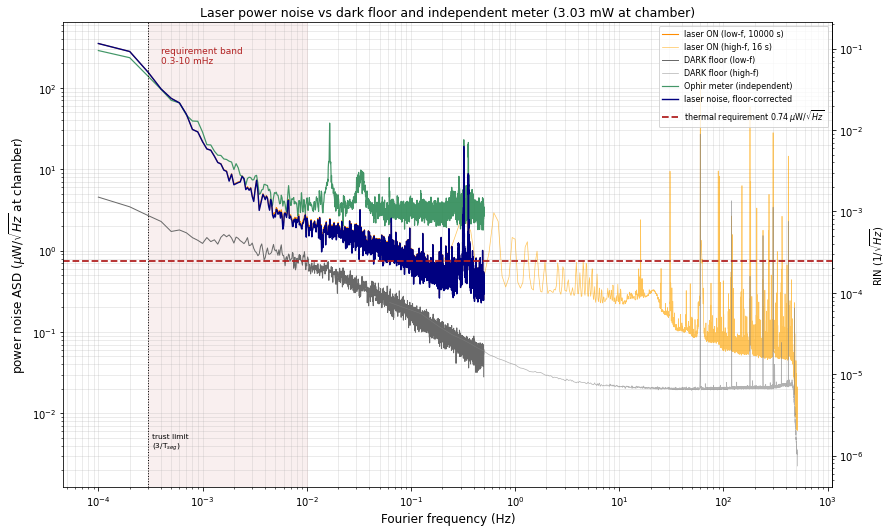

In [6]:
fig, ax = plt.subplots(figsize=(12.5, 7.5))
ax.loglog(f_lo[1:], uw_on_lo[1:], lw=1.1, color='darkorange', label=f'laser ON (low-f, {SEG_LO_S:.0f} s)')
ax.loglog(f_hi[1:], uw_on_hi[1:], lw=0.7, color='orange', alpha=0.65, label='laser ON (high-f, 16 s)')
ax.loglog(f_lo[1:], uw_dk_lo[1:], lw=1.0, color='dimgray', label='DARK floor (low-f)')
ax.loglog(f_hi[1:], uw_dk_hi[1:], lw=0.7, color='gray', alpha=0.6, label='DARK floor (high-f)')
ax.loglog(f_m[1:],  uw_m_lo[1:],  lw=1.2, color='seagreen', alpha=0.9,
          label='Ophir meter (independent)')
ax.loglog(f_lo[1:], uw_ex_lo[1:], lw=1.4, color='navy', label='laser noise, floor-corrected')

ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.8,
           label=f'thermal requirement {REQ_UW:.2f} $\\mu$W/$\\sqrt{{Hz}}$')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.axvline(3/SEG_LO_S, color='k', ls=':', lw=1.0)
ax.text(3/SEG_LO_S*1.1, ax.get_ylim()[0]*3, 'trust limit\n(3/T$_{seg}$)', fontsize=7.5, color='k')
ax.text(4e-4, 2e2, 'requirement band\n0.3-10 mHz', fontsize=9, color='firebrick')

ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('power noise ASD ($\\mu$W/$\\sqrt{Hz}$ at chamber)', fontsize=12)
ax.set_title(f'Laser power noise vs dark floor and independent meter '
             f'({P_CHAMBER_MW:.2f} mW at chamber)', fontsize=12.5)
sec = ax.secondary_yaxis('right', functions=(lambda x: x * 1e-3 / P_CHAMBER_MW,
                                             lambda r: r * P_CHAMBER_MW * 1e3))
sec.set_ylabel('RIN (1/$\\sqrt{Hz}$)', fontsize=10)
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

### Broadband levels by band — and where each instrument is limited

In [7]:
print(f"{'band':>20} | {'PD ON':>9} | {'DARK':>8} | {'laser':>9} | {'METER':>9} | {'ON/req':>8} | limited by")
print('-' * 104)
rows = [(3e-4,1e-3),(1e-3,3e-3),(3e-3,1e-2),(1e-2,1e-1),(0.1,0.5),
        (0.5,2),(2,10),(10,50),(50,200),(200,500)]
for lo, hi in rows:
    use_lo = hi <= 0.5
    ff, uo, ud, ue = ((f_lo, uw_on_lo, uw_dk_lo, uw_ex_lo) if use_lo
                      else (f_hi, uw_on_hi, uw_dk_hi, uw_ex_hi))
    b = (ff > lo) & (ff < hi)
    if not b.any():
        continue
    on_m, dk_m, ex_m = np.median(uo[b]), np.median(ud[b]), np.median(ue[b])
    bm = (f_m > lo) & (f_m < hi)
    mv = f'{np.median(uw_m_lo[bm]):9.3f}' if bm.any() else f'{"--":>9}'
    note = 'detector floor' if dk_m > 0.5 * on_m else ''
    print(f'{lo*1e3:8.2f}-{hi*1e3:8.2f} mHz | {on_m:9.3f} | {dk_m:8.3f} | {ex_m:9.3f} | '
          f'{mv} | {on_m/REQ_UW:7.1f}x | {note}')
print(f'\n(all in uW/sqrt(Hz); requirement = {REQ_UW:.3f})')

                band |     PD ON |     DARK |     laser |     METER |   ON/req | limited by
--------------------------------------------------------------------------------------------------------
    0.30-    1.00 mHz |    65.451 |    1.719 |    65.426 |    65.291 |    89.0x | 
    1.00-    3.00 mHz |     7.680 |    1.359 |     7.583 |    11.722 |    10.4x | 
    3.00-   10.00 mHz |     2.771 |    0.871 |     2.611 |     4.214 |     3.8x | 
   10.00-  100.00 mHz |     1.092 |    0.262 |     1.056 |     3.403 |     1.5x | 
  100.00-  500.00 mHz |     0.527 |    0.073 |     0.518 |     3.212 |     0.7x | 
  500.00- 2000.00 mHz |     0.489 |    0.035 |     0.488 |        -- |     0.7x | 
 2000.00-10000.00 mHz |     0.298 |    0.023 |     0.297 |        -- |     0.4x | 
10000.00-50000.00 mHz |     0.171 |    0.020 |     0.170 |        -- |     0.2x | 
50000.00-200000.00 mHz |     0.074 |    0.021 |     0.071 |        -- |     0.1x | 
200000.00-500000.00 mHz |     0.054 |    0.021 |     0.

## 4. Is the meter actually resolving, or is it quantization-limited?

The comparison above is only meaningful where the meter can see. An Ophir StarLab log is
written to fixed decimal places, so it has a **quantization step**; below that step the
meter reports a staircase and its spectrum flattens onto a floor. Quantization noise for
a step $q$ is $q/\sqrt{12}$ rms, spread roughly white across the band.

This decides how to read the previous table: where the meter sits on its own floor it
provides an **upper limit**, not a measurement.

In [8]:
u  = np.unique(pm_mW)
du = np.diff(u)
q  = du.min() if len(du) else np.nan

print('== Ophir meter resolution ==')
print(f'distinct values in the log : {len(u)}')
print(f'quantization step          : {q*1e3:.3f} uW')
print(f'record std                 : {pm_mW.std()*1e3:.3f} uW  = {pm_mW.std()/q:.2f} steps')
print(f'quantization noise q/sqrt12: {q/np.sqrt(12)*1e3:.3f} uW rms')
qfloor = (q/np.sqrt(12)) / np.sqrt(FS_LO/2) * 1e3
print(f'=> white-equivalent ASD floor at {FS_LO:.0f} Hz sampling: ~{qfloor:.3f} uW/sqrt(Hz)')
hf = (f_m > 0.05) & (f_m < 0.5)
print(f'   measured meter ASD, 50-500 mHz: {np.median(uw_m_lo[hf]):.3f} uW/sqrt(Hz)')
print(f'   requirement                   : {REQ_UW:.3f} uW/sqrt(Hz)')
print()
if np.median(uw_m_lo[hf]) > REQ_UW:
    print('The meter floor sits ABOVE the requirement -> the meter alone cannot verify')
    print('the requirement. It is useful where the laser noise exceeds that floor,')
    print('i.e. at the bottom of the band, where it independently corroborates the PD.')

== Ophir meter resolution ==
distinct values in the log : 6
quantization step          : 10.000 uW
record std                 : 6.317 uW  = 0.63 steps
quantization noise q/sqrt12: 2.887 uW rms
=> white-equivalent ASD floor at 1 Hz sampling: ~4.082 uW/sqrt(Hz)
   measured meter ASD, 50-500 mHz: 3.201 uW/sqrt(Hz)
   requirement                   : 0.735 uW/sqrt(Hz)

The meter floor sits ABOVE the requirement -> the meter alone cannot verify
the requirement. It is useful where the laser noise exceeds that floor,
i.e. at the bottom of the band, where it independently corroborates the PD.


## 5. Stability: raw scatter, drift, and what is left after detrending

`rotor_stability_flat.ipynb` cell 9's summary, applied to power. `std` is the raw scatter
over the settled record; `drift` is a straight-line fit across it; `std detrended` is what
survives removing that line. The gap between the last two is the honest statement of how
much of the instability is a slow trend rather than noise.

In [9]:
print(f"{'series':>10} {'hours':>7} {'std':>12} {'drift':>15} {'std detr':>12}")
print('-' * 62)
for nm, y, scale in [('PD ON', on_y, 1e3 / CTS_PER_MW),
                     ('PD DARK', dk_y, 1e3 / CTS_PER_MW),
                     ('METER',  pm_y, 1e3)]:
    ts = np.arange(len(y)) / FS_LO
    c  = np.polyfit(ts, y, 1)
    d  = y - np.polyval(c, ts)
    print(f'{nm:>10} {len(y)/3600:6.2f}h {y.std()*scale:10.2f}uW '
          f'{c[0]*3600*scale:+12.3f}uW/h {d.std()*scale:10.2f}uW')
print('\n(PD DARK is in counts scaled by the ON calibration -- an equivalent-power floor.)')

    series   hours          std           drift     std detr
--------------------------------------------------------------
     PD ON  21.76h       6.00uW       +0.219uW/h       5.84uW
   PD DARK  21.53h       0.19uW       -0.001uW/h       0.19uW
     METER  21.75h       6.15uW       +0.267uW/h       5.92uW

(PD DARK is in counts scaled by the ON calibration -- an equivalent-power floor.)


## 6. Does the wander average down?

`rotor_stability_flat.ipynb` cell 13's test. Smooth with successively longer boxcars: if
the fluctuation were white, each average of $N$ samples would narrow the scatter by
$\sqrt{N}$. Where the measured std falls **short** of that, the residual is correlated
wander — it does not average away, and watching longer buys less than it appears to.

In [10]:
print(f"{'boxcar':>8} | {'PD std':>10} {'white pred':>11} {'ratio':>7} | "
      f"{'METER std':>10} {'white pred':>11} {'ratio':>7}")
print('-' * 78)
for mins in [1, 5, 10, 30, 60]:
    cells = []
    for y, scale in [(on_y, 1e3 / CTS_PER_MW), (pm_y, 1e3)]:
        n = int(mins * 60 * FS_LO)
        if n >= len(y) // 2:
            cells += [np.nan] * 3; continue
        sm = uniform_filter1d(y.astype(np.float64), size=n)[n // 2: -n // 2]
        meas, pred = sm.std() * scale, y.std() * scale / np.sqrt(n)
        cells += [meas, pred, meas / pred]
    print(f'{mins:6d} m | {cells[0]:9.3f}u {cells[1]:10.3f}u {cells[2]:6.1f}x | '
          f'{cells[3]:9.3f}u {cells[4]:10.3f}u {cells[5]:6.1f}x')
print('\nratio = measured / white-noise prediction.  1x = averages down like white noise;')
print('>>1x = correlated wander that does not average away.')

  boxcar |     PD std  white pred   ratio |  METER std  white pred   ratio
------------------------------------------------------------------------------
     1 m |     5.908u      0.775u    7.6x |     5.444u      0.794u    6.9x
     5 m |     5.813u      0.347u   16.8x |     5.340u      0.355u   15.0x
    10 m |     5.665u      0.245u   23.1x |     5.185u      0.251u   20.6x
    30 m |     4.933u      0.142u   34.9x |     4.504u      0.145u   31.1x
    60 m |     3.751u      0.100u   37.5x |     3.504u      0.103u   34.2x

ratio = measured / white-noise prediction.  1x = averages down like white noise;
>>1x = correlated wander that does not average away.


## 7. Spectral lines (tagged *electronic* if also present in the dark record)

Lines are largely irrelevant to the rotor — they sit far above the mechanical corner and
are suppressed by γ/2πf — but they indicate pickup and would cost servo dynamic range.

   f (Hz) |  ON uW/rtHz |  DARK uW/rtHz |   x req | origin
--------------------------------------------------------------------
    59.94 |     126.465 |        27.029 |  172.0x | optical
   179.81 |      58.145 |         0.484 |   79.1x | optical
   299.69 |      28.132 |         3.415 |   38.3x | optical
   419.50 |      14.496 |         2.096 |   19.7x | optical
    89.12 |       9.541 |         0.020 |   13.0x | optical
    30.69 |       9.464 |         0.020 |   12.9x | optical
    91.25 |       8.212 |         0.021 |   11.2x | optical
   182.50 |       7.082 |         0.021 |    9.6x | optical
   150.56 |       6.289 |         0.021 |    8.6x | optical
   273.75 |       4.906 |         0.020 |    6.7x | optical
   209.00 |       3.335 |         0.021 |    4.5x | optical
   119.88 |       2.666 |         4.094 |    3.6x | electronic (in dark)
   365.00 |       2.642 |         0.022 |    3.6x | optical
    16.00 |       2.394 |         0.021 |    3.3x | optical
   239.75 |       1

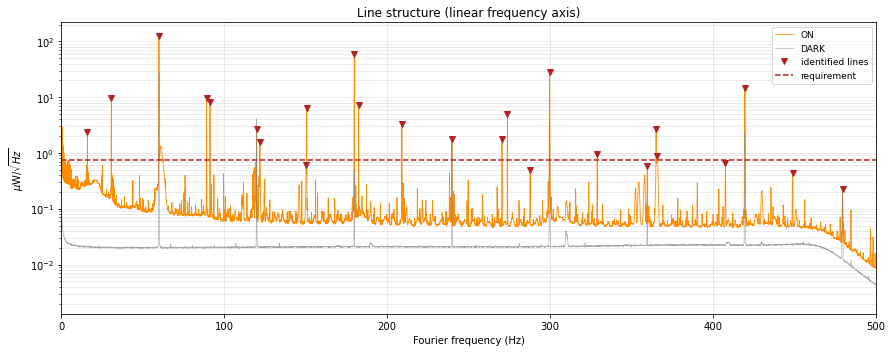

In [11]:
m = f_hi > 0.2
fm, um_on, um_dk = f_hi[m], uw_on_hi[m], uw_dk_hi[m]
base = median_filter(um_on, size=101)
pk, _ = find_peaks(um_on / base, height=8, distance=3)
order = np.argsort(um_on[pk])[::-1]

print(f"{'f (Hz)':>9} | {'ON uW/rtHz':>11} | {'DARK uW/rtHz':>13} | {'x req':>7} | origin")
print('-' * 68)
for i in pk[order][:15]:
    electronic = um_dk[i] > 0.5 * um_on[i]
    print(f'{fm[i]:9.2f} | {um_on[i]:11.3f} | {um_dk[i]:13.3f} | {um_on[i]/REQ_UW:6.1f}x | '
          f'{"electronic (in dark)" if electronic else "optical"}')

fig, ax = plt.subplots(figsize=(12.5, 5))
ax.semilogy(f_hi[1:], uw_on_hi[1:], lw=0.8, color='darkorange', label='ON')
ax.semilogy(f_hi[1:], uw_dk_hi[1:], lw=0.6, color='gray', alpha=0.7, label='DARK')
ax.semilogy(fm[pk], um_on[pk], 'v', ms=6, color='firebrick', label='identified lines')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.5, label='requirement')
ax.set_xlim(0, 500); ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('$\\mu$W/$\\sqrt{Hz}$')
ax.set_title('Line structure (linear frequency axis)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. PD vs meter in the time domain

The meter's internal clock is wrong (the StarLab header reads 2006), so the two records
cannot be aligned by absolute timestamp. Two routes:

1. **Beam-block fiducials** — a deliberate 10–15 s block puts an unambiguous edge in
   *both* records. If blocks are present in both, the offset is read straight off.
2. **Cross-correlation of the fluctuations**, as a fallback. Done broadband this is a
   weak test, because the meter is quantization-limited above ~1 mHz and shares little
   with the PD there. It is run here **in-band** — both smoothed and detrended first —
   so it tests the drift the two should genuinely share.

In [12]:
b_pd, b_m = blocks['PD ON'], blocks['METER']
if b_pd and b_m:
    off = b_m[0]['start_s'] - b_pd[0]['start_s']
    print(f'FIDUCIAL ALIGNMENT: first block at PD t={b_pd[0]["start_s"]:.1f} s, '
          f'meter t={b_m[0]["start_s"]:.1f} s  ->  offset {off:+.1f} s')
    if len(b_pd) > 1 and len(b_m) > 1:
        off2 = b_m[-1]['start_s'] - b_pd[-1]['start_s']
        print(f'                   last block offset {off2:+.1f} s  '
              f'-> clock drift over the run {off2-off:+.1f} s')
else:
    print('No beam-block fiducial present in BOTH records for this pair.')
    print(f'  PD ON blocks : {len(b_pd)} (record opens with the laser turning on)')
    print(f'  METER blocks : {len(b_m)} (meter logging started after the laser settled)')
    print('  -> absolute alignment unavailable here; the machinery above is ready for')
    print('     the next run, where the beam is blocked deliberately at start and end.')

# in-band correlation: smooth to SMOOTH_S, detrend, then correlate
SMOOTH_S = 100
n_common = min(len(on_y), len(pm_y))
a = on_y[:n_common] / CTS_PER_MW
b = pm_y[:n_common]
ns = int(SMOOTH_S * FS_LO)
a = uniform_filter1d(a, ns)[ns:-ns]; b = uniform_filter1d(b, ns)[ns:-ns]
ts = np.arange(len(a))
a = a - np.polyval(np.polyfit(ts, a, 1), ts)
b = b - np.polyval(np.polyfit(ts, b, 1), ts)
if a.std() > 0 and b.std() > 0:
    xc  = correlate(a - a.mean(), b - b.mean(), mode='full')
    lag = int(np.arange(-len(a) + 1, len(a))[np.argmax(xc)])
    s1, s2 = slice(max(0, lag), None), slice(max(0, -lag), None)
    nlap = min(len(a[s1]), len(b[s2]))
    r = float(np.corrcoef(a[s1][:nlap], b[s2][:nlap])[0, 1]) if nlap > 10 else np.nan
    print(f'\nin-band ({SMOOTH_S} s smoothing, detrended): best lag {lag:+d} s, r = {r:.3f}')
    print('(the records are not simultaneous start-to-start, so a large lag is expected;')
    print(' r is the meaningful number.)')

No beam-block fiducial present in BOTH records for this pair.
  PD ON blocks : 3 (record opens with the laser turning on)
  METER blocks : 0 (meter logging started after the laser settled)
  -> absolute alignment unavailable here; the machinery above is ready for
     the next run, where the beam is blocked deliberately at start and end.

in-band (100 s smoothing, detrended): best lag +0 s, r = 0.946
(the records are not simultaneous start-to-start, so a large lag is expected;
 r is the meaningful number.)


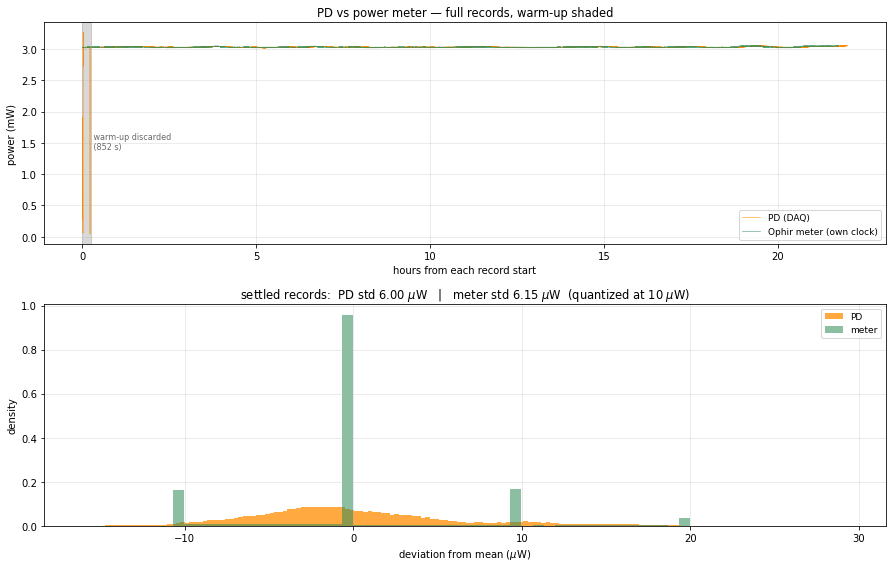

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8))
t_on_h = (np.arange(len(on['y_lo'])) / FS_LO) / 3600
axes[0].plot(t_on_h, on['y_lo'] / CTS_PER_MW, lw=0.5, color='darkorange', label='PD (DAQ)')
axes[0].axvspan(0, i_on / 3600, color='gray', alpha=0.3)
axes[0].text(i_on / 3600 * 1.05, np.median(on_y) / CTS_PER_MW * 0.5,
             f' warm-up discarded\n ({i_on} s)', fontsize=8, color='dimgray', va='center')
axes[0].plot((gp_m - gp_m[0]) / 3600, pm_1, lw=0.6, color='seagreen', alpha=0.8,
             label='Ophir meter (own clock)')
axes[0].set_xlabel('hours from each record start'); axes[0].set_ylabel('power (mW)')
axes[0].set_title('PD vs power meter — full records, warm-up shaded', fontsize=11.5)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

dev_pd = (on_y / CTS_PER_MW - np.mean(on_y / CTS_PER_MW)) * 1e3
dev_m  = (pm_y - pm_y.mean()) * 1e3
axes[1].hist(dev_pd, bins=150, color='darkorange', density=True, alpha=0.75, label='PD')
axes[1].hist(dev_m,  bins=60,  color='seagreen',  density=True, alpha=0.55, label='meter')
axes[1].set_xlabel('deviation from mean ($\\mu$W)'); axes[1].set_ylabel('density')
axes[1].set_title(f'settled records:  PD std {dev_pd.std():.2f} $\\mu$W   |   '
                  f'meter std {dev_m.std():.2f} $\\mu$W  (quantized at {q*1e3:.0f} $\\mu$W)',
                  fontsize=11.5)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Shot-noise context

How much of the measured floor is fundamental photon statistics, and how much is
implementation?

In [14]:
hf = (f_hi > 100) & (f_hi < 400)
floor_uW  = float(np.median(uw_on_hi[hf]))
floor_rin = floor_uW * 1e-3 / P_CHAMBER_MW
shot_rin  = np.sqrt(2 * E_CHARGE / (RESPONSIVITY * P_CHAMBER_MW * 1e-3))

print(f'measured floor (100-400 Hz) : {floor_uW:.4f} uW/sqrt(Hz) = {floor_rin:.2e} /sqrt(Hz)')
print(f'shot-noise RIN at {P_CHAMBER_MW:.2f} mW  : {shot_rin:.2e} /sqrt(Hz) '
      f'-> {shot_rin*P_CHAMBER_MW*1e3:.5f} uW/sqrt(Hz)')
print(f'measured floor is {floor_rin/shot_rin:.0f}x above shot noise '
      '(implementation-limited, not fundamental)')

measured floor (100-400 Hz) : 0.0593 uW/sqrt(Hz) = 1.96e-05 /sqrt(Hz)
shot-noise RIN at 3.03 mW  : 1.23e-08 /sqrt(Hz) -> 0.00004 uW/sqrt(Hz)
measured floor is 1591x above shot noise (implementation-limited, not fundamental)


## 10. Where this leaves us

Read the numbers above, but the structure of the answer:

- **The data-quality gate is not optional.** The ON record opens with the laser turning
  on; leaving that in inflates the record's std by more than an order of magnitude and
  leaks into the lowest Welch bins. Any low-frequency claim made without it is an
  artefact of the transient, not a property of the laser.
- **The band is now actually covered.** 10000 s segments reach 0.1 mHz resolution with
  ~15 averages, trustworthy down to 0.3 mHz — the bottom of the requirement band, rather
  than the 3.33 mHz floor of the previous 300 s segments.
- **Two independent instruments agree at the bottom of the band.** Where the meter is
  above its own quantization floor, it corroborates the PD. That is the strongest
  statement available without new hardware: the low-frequency wander is in the *laser*,
  not in the PD's filter stack.
- **Where the meter is on its floor it only sets an upper limit** — above ~1 mHz the PD
  is the more sensitive instrument, and the meter cannot verify the requirement at all,
  since its quantization floor sits above it.
- **The excess over the requirement is concentrated at the bottom of the band.** That is
  where any servo or power-stabilisation effort has to be aimed; the broadband floor is
  far from fundamental (see the shot-noise ratio above), so there is headroom.

**Next run.** Blocking the beam for ~10–15 s at the start and end stamps a fiducial into
both records and turns Section 8's alignment from unavailable into a measured number
(including any clock drift across the run). Repeating at a higher operating power tests
whether the low-frequency wander scales with power — but note that both real RIN and any
multiplicative transmission drift scale the same way, so the *meter* remains the
discriminator, not the power step.